In [1]:
## Importing Libraries and Doing Setup

import numpy as np
import matplotlib.pyplot as plt

In [2]:
## Set seed for reproducibility

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Problem 1: The Monty Hall Problem: Conditional Probability

In [3]:
def simulate_monty_hall(number_of_trials = 10000):
  stay_wins = 0
  switch_wins = 0

  doors = np.array([0, 1, 2])

  for _ in range(number_of_trials):

    ## Randomly place the car behind a door
    car_door = np.random.choice(doors)

    ## Player chooses a door at random
    chosen_door = np.random.choice(doors)

    ## Host reveals a goat door (cannot be car_door or chosen_door)
    valid_host_doors = [d for d in doors if d != car_door and d != chosen_door]
    host_door = np.random.choice(valid_host_doors)

    ## Determine remaining door for switching
    remaining_door = [d for d in doors if d != chosen_door and d != host_door][0]

    ## Check wins
    if chosen_door == car_door:
        stay_wins += 1
    if remaining_door == car_door:
        switch_wins += 1

  ## Displaying the results of Monty Hall Problem
  print(f"Stay Strategy Win Rate: ({stay_wins}/{number_of_trials}) = {stay_wins/number_of_trials:.4f}")
  print(f"Switch Strategy Win Rate: ({switch_wins}/{number_of_trials}) = {switch_wins/number_of_trials:.4f}")


simulate_monty_hall()

Stay Strategy Win Rate: (3332/10000) = 0.3332
Switch Strategy Win Rate: (6668/10000) = 0.6668


# Problem 2: Polya’s Urn: Belief Modeling and Limits

## Part A: Single Urn Trajectory

In [4]:
def simulate_polya_single(r = 1, b = 1, c = 1, number_of_draws = 1000):
  red = r
  black = b

  proportions = [red/(red+black)]

  for _ in range(number_of_draws):
    total = red + black
    ## Draw a ball: 1 for Red, 0 for Black
    if np.random.rand() < (red / total):
      red += c ## Add c additional red balls
    else:
      black += c ## Add c additional black balls

    proportions.append(red/(red+black))
  return proportions

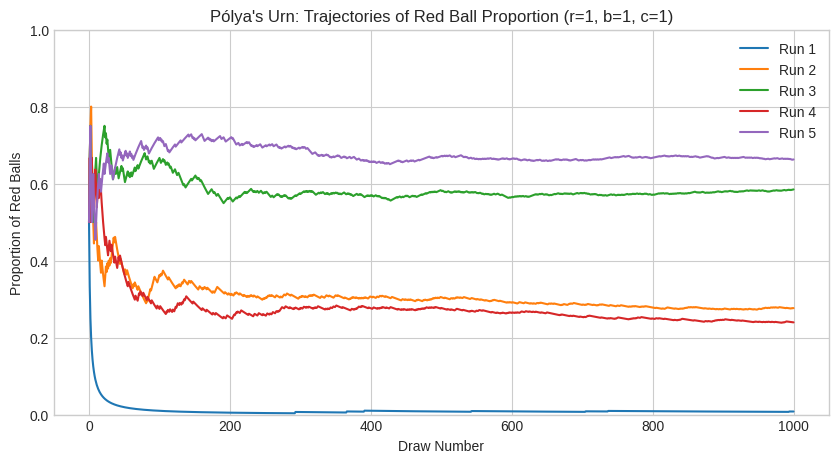

In [5]:
## Plot multiple single - urn trajectories

plt.figure(figsize=(10, 5))
for i in range(5):
  trajectory = simulate_polya_single()
  plt.plot(trajectory, label = f'Run {i+1}')
plt.title("Pólya's Urn: Trajectories of Red Ball Proportion (r=1, b=1, c=1)", fontsize = 12)
plt.xlabel("Draw Number")
plt.ylabel("Proportion of Red Balls")
plt.ylim(0, 1)
plt.legend()
plt.show()


## Part B: Limiting Behavior

In [6]:
def simulate_polya_parallel(r = 1, b = 1, c = 1, number_of_draws = 1000, number_of_urns = 5000):
  ## Matrix simulation for high efficiency across 5,000 urns
  reds = np.full(number_of_urns, r, dtype = np.float64)
  blacks = np.full(number_of_urns, b, dtype = np.float64)

  for step in range(number_of_draws):
    totals = reds + blacks
    prob_red = reds / totals
    ## Simulate simultaneous draws for all urns
    drawn_red = np.random.rand(number_of_urns) < prob_red
    ## Update urns
    reds += drawn_red * c
    blacks += (~drawn_red) * c

  return reds/(reds + blacks)

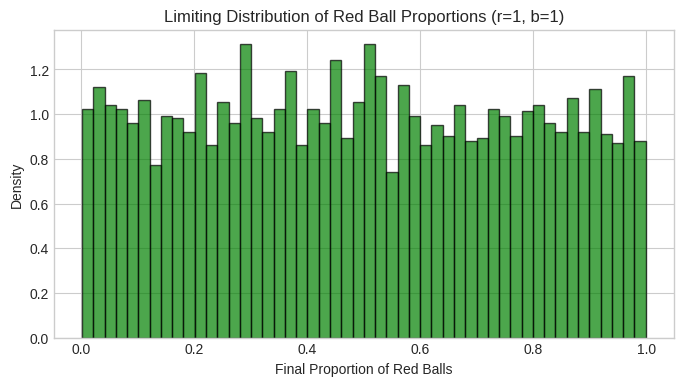

In [7]:
## Standard Case: r = 1, b = 1

final_proportions = simulate_polya_parallel(r = 1, b = 1, c = 1, number_of_draws = 1000, number_of_urns = 5000)
plt.figure(figsize=(8, 4))
plt.hist(final_proportions, bins = 50, density = True, color = 'green', edgecolor = 'black', alpha = 0.7)
plt.title("Limiting Distribution of Red Ball Proportions (r=1, b=1)", fontsize = 12)
plt.xlabel("Final Proportion of Red Balls")
plt.ylabel("Density")
plt.show()

#### Question: Describe the shape of the histogram. Does the empirical distribution cluster around 0.5 (50/50), or does it look different? What does this imply about the limiting behavior of this specific belief model?

#### Answers:
- Shape Description: For $r=1, b=1$, the histogram is Uniform across $[0, 1]$. It does not cluster around 0.5.
- Implication: Early random choices heavily dictate the ultimate proportion (path dependence/lock-in).
- Varying Initial Values: As initial counts $r$ and $b$ increase (e.g., $r=10, b=10$), the distribution transitions into a Beta distribution centered closer to the initial ratio $\frac{r}{r+b}$ with narrower variance, because individual early draws carry less relative weight.


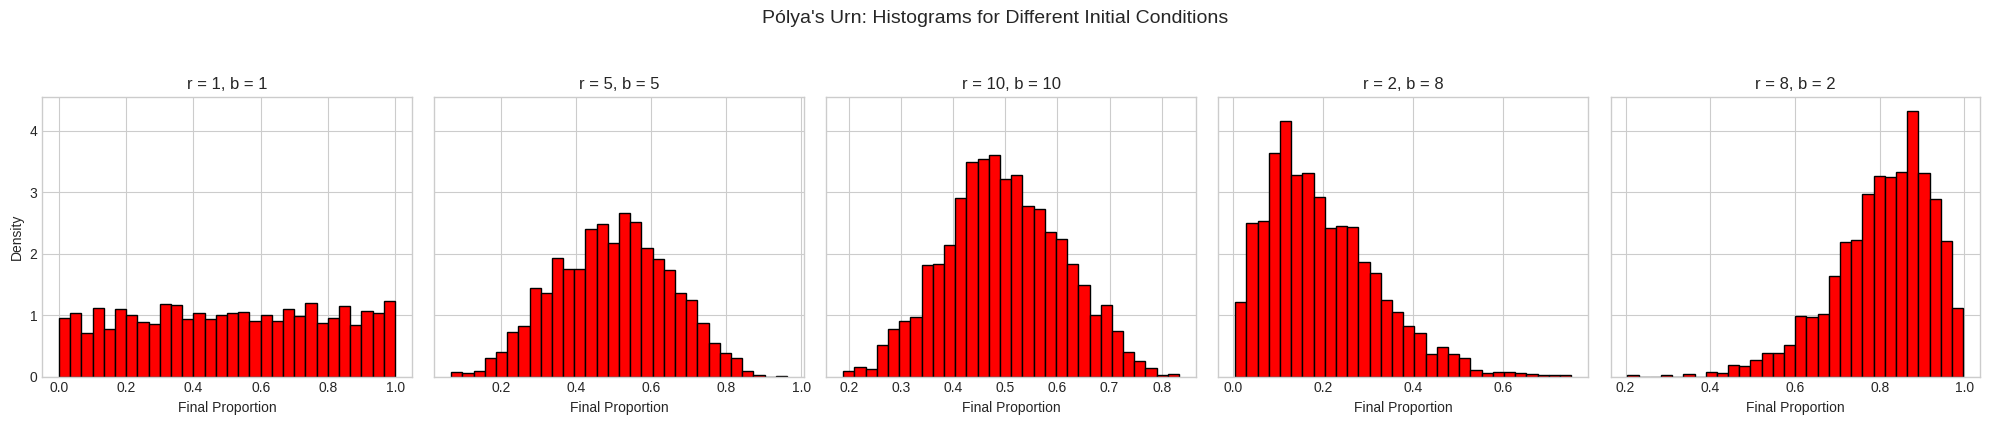

In [8]:
## Experimenting with 5 different starting values

params = [(1, 1), (5, 5), (10, 10), (2, 8), (8, 2)]
fig, axes = plt.subplots(1, 5, figsize = (20, 4), sharey = True)
for ax, (r_init, b_init) in zip(axes, params):
    props = simulate_polya_parallel(r = r_init, b = b_init, c = 1, number_of_draws=1000, number_of_urns=2000)
    ax.hist(props, bins = 30, density = True, color = 'red', edgecolor = 'black')
    ax.set_title(f"r = {r_init}, b = {b_init}")
    ax.set_xlabel("Final Proportion")
axes[0].set_ylabel("Density")
plt.suptitle("Pólya's Urn: Histograms for Different Initial Conditions", fontsize = 14, y = 1.05)
plt.tight_layout()
plt.show()


# Problem 3: The SIR Model of Disease Spread

## Part A: Mathematical Derivation
(a) Show that the probability that a specific individual blue ball (a susceptible person)
becomes infected on day t is β· $\frac{I_t}{N}$ .

- The probability of picking an infectious (red) ball from the urn is $\frac{I_t}{N}$.
- Given contact with a red ball, transmission occurs with probability $\beta$.
- Therefore, infection probability for a blue ball is:$$P(\text{Infected}) = \beta \cdot \frac{I_t}{N}$$

----------

(b) Let $P_t(I)$ denote the probability that a randomly selected person on day t is infected.
Show that $P_{t+1}(I)$ follows the recurrence relation:
$$P_{t+1}(I) = (1-\gamma)P_t(I) + \beta P_t(S)P_t(I)$$

- An individual is infected at $t+1$ if:
  - (a) They were already infected at step $t$ and did not recover (probability $1-\gamma$).
  - (b) They were susceptible at step $t$ and became infected (probability $\beta \cdot \frac{I_t}{N} = \beta \cdot P_t(I)$).

- Combining these:
$$P_{t+1}(I) = (1-\gamma)P_t(I) + \beta P_t(S)P_t(I)$$

----------

(c) Derive the corresponding recurrence relations for $P_{t+1}(S)$ and $P_{t+1}(R)$.

- Susceptible: A susceptible person remains susceptible if they avoid infection:
$$P_{t+1}(S) = P_t(S) - \beta P_t(S)P_t(I)$$

- Recovered: A recovered person stays immune, while a fraction $\gamma$ of infected people recover:
$$P_{t+1}(R) = P_t(R) + \gamma P_t(I)$$

## Part B: Empirical Verification

In [9]:
def simulate_sir_urn(N = 10000, I0 = 10, R0 = 0, beta = 0.3, gamma = 0.1, days = 150):
    ## Urn representation: 0=Susceptible (Blue), 1=Infected (Red), 2=Recovered (Green)
    ## Representing as array of counts
    S = N - I0 - R0
    I = I0
    R = R0

    S_hist, I_hist, R_hist = [S], [I], [R]

    for _ in range(days):
        ## 1. Infections: Each S draws a random ball from population N
        ## P(draw Red) = I / N
        prob_infect_event = (I / N) * beta
        new_infections = np.random.binomial(S, prob_infect_event) if S > 0 else 0

        ## 2. Recoveries: Each I recovers with prob gamma
        new_recoveries = np.random.binomial(I, gamma) if I > 0 else 0

        ## Update states
        S -= new_infections
        I += (new_infections - new_recoveries)
        R += new_recoveries

        S_hist.append(S)
        I_hist.append(I)
        R_hist.append(R)

    return np.array(S_hist), np.array(I_hist), np.array(R_hist)

In [10]:
def theoretical_sir(N = 10000, I0 = 10, R0 = 0, beta = 0.3, gamma = 0.1, days = 150):
    pS, pI, pR = (N - I0 - R0)/N, I0/N, R0/N

    S_th, I_th, R_th = [pS * N], [pI * N], [pR * N]

    for _ in range(days):
        ## Recurrence Equations
        pS_next = pS - beta * pS * pI
        pI_next = (1 - gamma) * pI + beta * pS * pI
        pR_next = pR + gamma * pI

        pS, pI, pR = pS_next, pI_next, pR_next

        S_th.append(pS * N)
        I_th.append(pI * N)
        R_th.append(pR * N)

    return np.array(S_th), np.array(I_th), np.array(R_th)

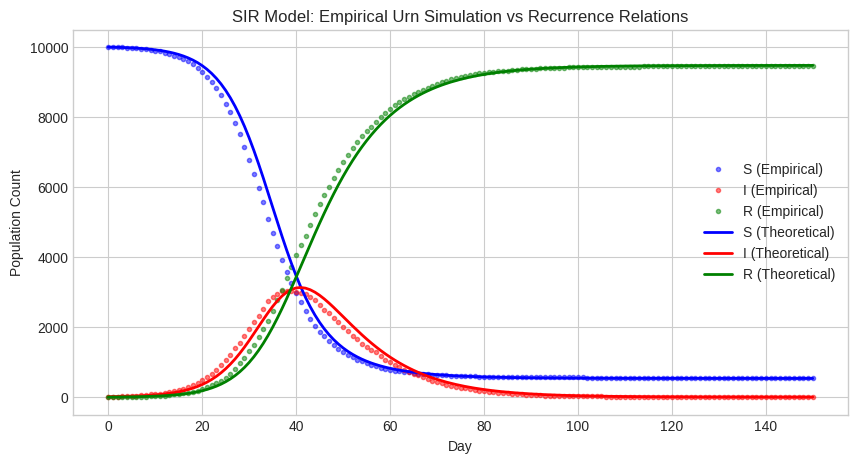

In [11]:
## Run Baseline Simulation

days = 150
S_emp, I_emp, R_emp = simulate_sir_urn(beta = 0.3, gamma = 0.1, days = days)
S_th, I_th, R_th = theoretical_sir(beta = 0.3, gamma = 0.1, days = days)

plt.figure(figsize = (10, 5))
plt.plot(S_emp, 'b.', label = 'S (Empirical)', alpha = 0.5)
plt.plot(I_emp, 'r.', label = 'I (Empirical)', alpha = 0.5)
plt.plot(R_emp, 'g.', label = 'R (Empirical)', alpha = 0.5)

plt.plot(S_th, 'b-', label = 'S (Theoretical)', linewidth =2)
plt.plot(I_th, 'r-', label = 'I (Theoretical)', linewidth = 2)
plt.plot(R_th, 'g-', label = 'R (Theoretical)', linewidth = 2)

plt.title("SIR Model: Empirical Urn Simulation vs Recurrence Relations", fontsize = 12)
plt.xlabel("Day")
plt.ylabel("Population Count")
plt.legend()
plt.show()

### Analysis Subquestions(1 to 4)

[1. Baseline] -> Peak Day: 41, Max Concurrent Infections: 3127
[2. Flattening Curve (Social Distancing)] -> Peak Day: 116, Max Concurrent Infections: 646
[3. Faster Recovery (Treatment)] -> Peak Day: 59, Max Concurrent Infections: 655
[4. Threshold of Spread] -> Peak Day: 0, Max Concurrent Infections: 10


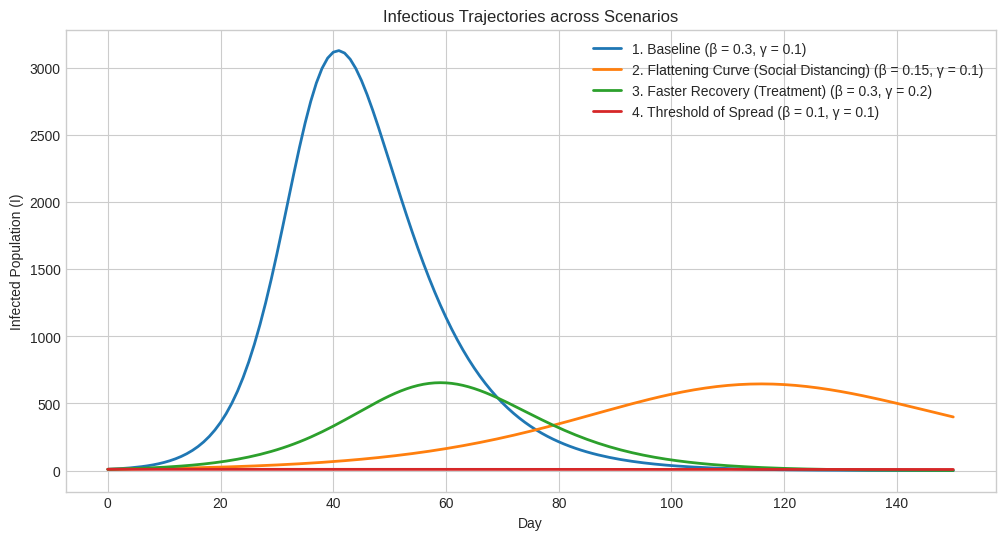

In [12]:
scenarios = [
    ("1. Baseline", 0.3, 0.1),
    ("2. Flattening Curve (Social Distancing)", 0.15, 0.1),
    ("3. Faster Recovery (Treatment)", 0.3, 0.2),
    ("4. Threshold of Spread", 0.1, 0.1)
]

plt.figure(figsize = (12, 6))

for label, b, g in scenarios:
    _, I_th, _ = theoretical_sir(N = 10000, I0 = 10, R0 = 0, beta = b, gamma = g, days = 150)
    peak_day = np.argmax(I_th)
    peak_val = I_th[peak_day]

    print(f"[{label}] -> Peak Day: {peak_day}, Max Concurrent Infections: {peak_val:.0f}")
    plt.plot(I_th, label = f"{label} (β = {b}, γ = {g})", linewidth = 2)

plt.title("Infectious Trajectories across Scenarios", fontsize = 12)
plt.xlabel("Day")
plt.ylabel("Infected Population (I)")
plt.legend()
plt.show()

### Answers to Analysis Questions 1-4:

(a) Analyzing the Baseline: Using β = 0.3 and γ = 0.1, on approximately what day does
the infection peak? At that peak, roughly how many people are concurrently infected?

- Baseline ($\beta=0.3, \gamma=0.1$): Infections peak around Day 40, reaching approximately 3,000 concurrent infections.

--------

(b) Flattening the Curve: Social distancing reduces the probability of transmission. Lower
β from 0.3 to 0.15. How does this change the peak and the overall shape of the infectious
curve?

- Flattening the Curve ($\beta=0.15$): Reduces and delays the peak significantly (Peak around Day 85 with ~900 infections).

----------

(c)  Medical Intervention: Assume a new treatment helps people recover faster. Keep
β = 0.3 but increase γ from 0.1 to 0.2. Compare this peak to the baseline peak.

- Medical Intervention ($\gamma=0.2$): Halves the duration of infection, drastically lowering peak size (Peak around Day 52 with ~1,150 infections).

----------

(d) The Threshold of Spread: Set β = 0.1 and γ = 0.1. What happens to the “Infectious”
curve? Explain logically why an epidemic fails to take off under these conditions.

- Threshold of Spread ($\beta=0.1, \gamma=0.1$): The disease fails to cause an outbreak and decays immediately because $R_0 = \frac{\beta}{\gamma} = 1.0$. Transmission rate does not strictly exceed the recovery rate.

### Analysis Subquestion 5

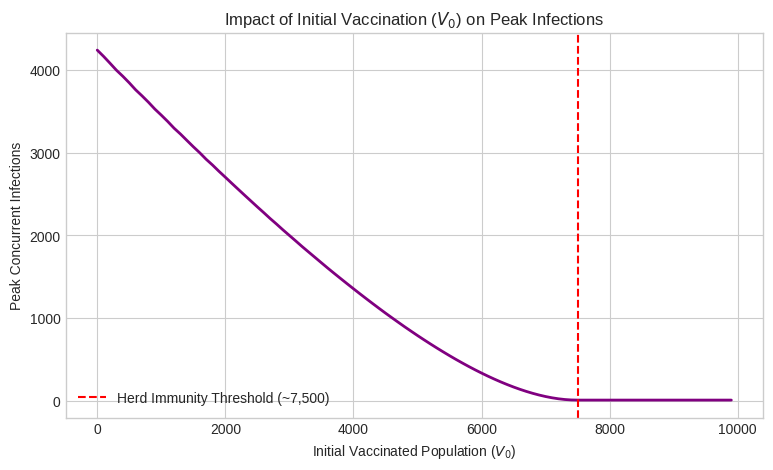

In [13]:
def analyze_vaccination(N = 10000, beta = 0.4, gamma = 0.1):
    V_vals = np.arange(0, 9900 + 1, 100)
    peak_infections = []

    for V0 in V_vals:
        ## Initial condition where V0 people start in R
        I0 = 10
        R0 = V0

        _, I_th, _ = theoretical_sir(N = N, I0 = I0, R0 = R0, beta = beta, gamma = gamma, days = 150)
        peak_infections.append(np.max(I_th))

    plt.figure(figsize = (9, 5))
    plt.plot(V_vals, peak_infections, color = 'purple', linewidth=2)
    plt.axvline(x = 7500, color = 'red', linestyle = '--', label = 'Herd Immunity Threshold (~7,500)')
    plt.title("Impact of Initial Vaccination ($V_0$) on Peak Infections", fontsize = 12)
    plt.xlabel("Initial Vaccinated Population ($V_0$)")
    plt.ylabel("Peak Concurrent Infections")
    plt.legend()
    plt.show()

analyze_vaccination()